In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# LOAD AND EDA

In [ ]:
df = pd.read_csv("insurancedata.csv")

In [ ]:
df.head()

,district,region,spendtype,percapgdp,avgcancerspend
0,1,North,Insurance,54822.32372,354097.0520
1,2,North,Insurance,44447.65969,423805.8963
2,3,North,Insurance,47444.91232,339665.6173
3,4,North,Insurance,40322.25256,384887.2437
4,5,North,Insurance,49366.17764,362895.3526


In [ ]:
# here dependant value is continous , so no need to chck balance in dependant # like equal 0 and 1 like that

,count
avgcancerspend,
528150.1021,1
354097.0520,1
423805.8963,1
339665.6173,1
384887.2437,1
...,...
308843.4725,1
313491.5950,1
282504.3311,1


In [ ]:
df.shape

(620, 5)

In [ ]:
df['region'].unique()

array(['North', 'East', 'West', 'South'], dtype=object)

In [ ]:
df['region'].value_counts()

,count
region,
North,155
East,155
West,155
South,155


In [ ]:
df['spendtype'].value_counts()

,count
spendtype,
Insurance,620


In [ ]:
df.describe()

,district,percapgdp,avgcancerspend
count,620.000000,620.000000,620.000000
mean,310.500000,45030.381745,378023.611985
std,179.122863,10363.028564,136983.995348
min,1.000000,19154.741670,119999.545400
25%,155.750000,37054.194693,263714.761025
50%,310.500000,47180.536255,393918.785100
75%,465.250000,52953.185985,490550.758725
max,620.000000,68366.672160,644532.690500


<ipython-input-27-331ac2a7116d>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['district'])


<Axes: xlabel='district', ylabel='Density'>

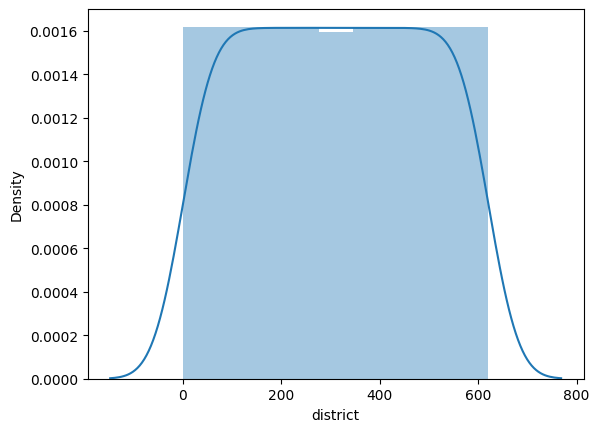

In [ ]:
sns.distplot(df['district'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   district        620 non-null    int64  
 1   region          620 non-null    object 
 2   spendtype       620 non-null    object 
 3   percapgdp       620 non-null    float64
 4   avgcancerspend  620 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 24.3+ KB


change category to numerical

In [ ]:
df = pd.get_dummies(df,columns= ['region'],drop_first=True,dtype=int)

In [ ]:
df.tail()

,district,spendtype,percapgdp,avgcancerspend,region_North,region_South,region_West
615,616,Insurance,58201.10318,553099.2519,0,1,0
616,617,Insurance,48011.21789,546482.6506,0,1,0
617,618,Insurance,57763.73355,535415.5338,0,1,0
618,619,Insurance,54595.69918,429286.6835,0,1,0
619,620,Insurance,55419.96532,528150.1021,0,1,0


# TRAIN AND TEST

In [ ]:
df.head()

,district,spendtype,percapgdp,avgcancerspend,region_North,region_South,region_West
0,1,Insurance,54822.32372,354097.0520,1,0,0
1,2,Insurance,44447.65969,423805.8963,1,0,0
2,3,Insurance,47444.91232,339665.6173,1,0,0
3,4,Insurance,40322.25256,384887.2437,1,0,0
4,5,Insurance,49366.17764,362895.3526,1,0,0


In [ ]:
y = df['avgcancerspend'] #dependant

In [ ]:
x = df[['percapgdp','region_West','region_North','region_South']] # independant

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state=100)

Why is random_state Important?

Ensures reproducibility → If you run the code multiple times with the same random_state, you will get the same split.


Without it, each execution might produce different train-test splits, affecting model performance.

In [ ]:
x_train.shape

(434, 4)

In [ ]:
x_test.shape

(186, 4)

In [ ]:
y_train.shape

(434,)

In [ ]:
y_test.shape

(186,)

# MODEL TRAINING

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lm = LinearRegression()

TRAIN/FIT LM on TRAIN DATA

In [ ]:
lm.fit(x_train,y_train)

LinearRegression()

CO-effiecent of each indepentant variable

In [ ]:
lm.coef_

array([-4.80241737e-01,  2.76122138e+05,  1.78418102e+05,  3.71283121e+05])

In [ ]:
pred_train = lm.predict(x_train)

In [ ]:
pred_train

In [ ]:
pred_test= lm.predict(x_test)

In [ ]:
pred_test

In [ ]:
from sklearn import metrics

In [ ]:
metrics.r2_score(y_train,pred_train)

0.9341190824336909

0.9341190824336909 >0.9 --> GOOD

In [ ]:
metrics.r2_score(y_test,pred_test)

0.9130808577662184

0.9130808577662184 >0.9 --> GOOD

Text(0, 0.5, 'prediction_test')

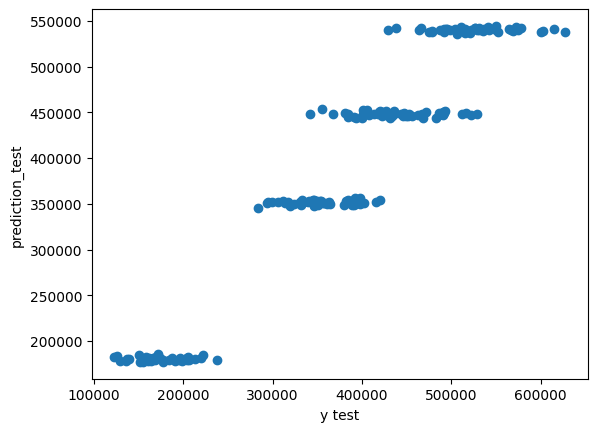

In [ ]:
plt.scatter(y_test,pred_test)
plt.xlabel('y test')
plt.ylabel('prediction_test')

# METRICS TEST

In [ ]:
print("MAE:",metrics.mean_absolute_error(y_test,pred_test))
print("MSE:",metrics.mean_squared_error(y_test,pred_test))
print("RMSE:",np.sqrt(metrics.mean_squared_error(y_test,pred_test)))

MAE: 31026.51055515335
MSE: 1496796728.0761306
RMSE: 38688.457297702254


In [ ]:
#MAPE

<ipython-input-68-f80ace2d199e>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - pred_test),bins=50)


<Axes: xlabel='avgcancerspend', ylabel='Density'>

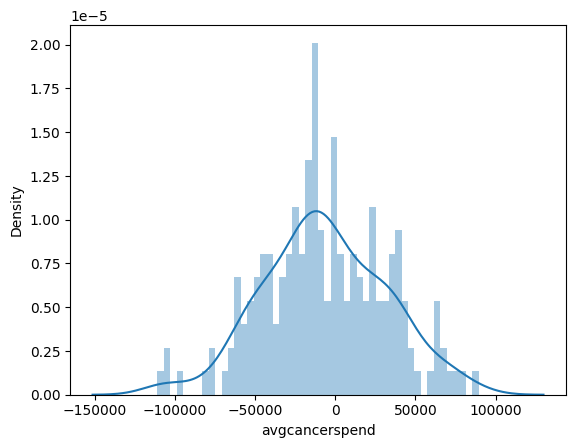

In [ ]:
sns.distplot((y_test - pred_test),bins=50)

In [ ]:
coeffecients = pd.DataFrame(lm.coef_,x.columns)
coeffecients.columns = ['coeff']
coeffecients


,coeff
percapgdp,-0.480242
region_West,276122.137685
region_North,178418.101948
region_South,371283.120522


#HEAT MAP

<Axes: >

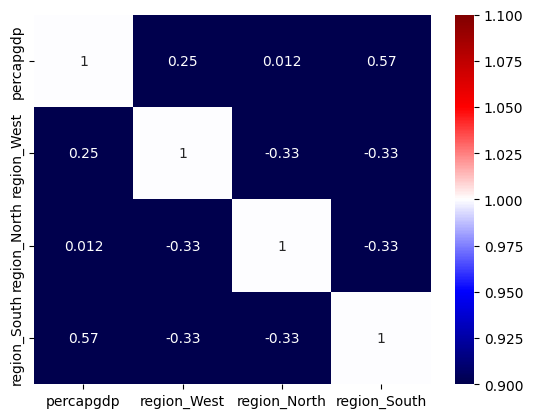

In [ ]:
sns.heatmap(df[['percapgdp','region_West','region_North','region_South']].corr(),annot=True,vmin=1,vmax=1,cmap='seismic')

In [ ]:
from sklearn import metrics

In [ ]:
metrics.r2_score(y_test,pred_test)

0.9130808577662184

In [ ]:
predictions_train = lm.predict(X_train)

In [ ]:
metrics.r2_score(y_train,pred_train)

0.9341190824336909

In [ ]:
# Testing
metrics.mean_absolute_error(y_test,pred_test)

31026.51055515335

In [ ]:
# Testing
metrics.mean_squared_error(y_test,pred_test)

1496796728.0761306

In [ ]:
# Testing
np.sqrt(metrics.mean_squared_error(y_test, pred_test))

np.float64(38688.457297702254)

In [ ]:
#MAPE
MAPE = np.mean(np.abs((y_train - pred_train) / y_train)) * 100
float(MAPE)

8.370717906527135

# Steps
1. Pre-processing
2. Split into X and y
3. Split the X and y into training and testting
4. model.fit (X_train,y_train)
5. model.predict(X_test)
6. from sklearn import metrics
7. metrics.r2_score
8. metrics.mean_absolute_error
9. metrics.mean_squared_error
10.np.sqrt(metrics.mean_squared_error)

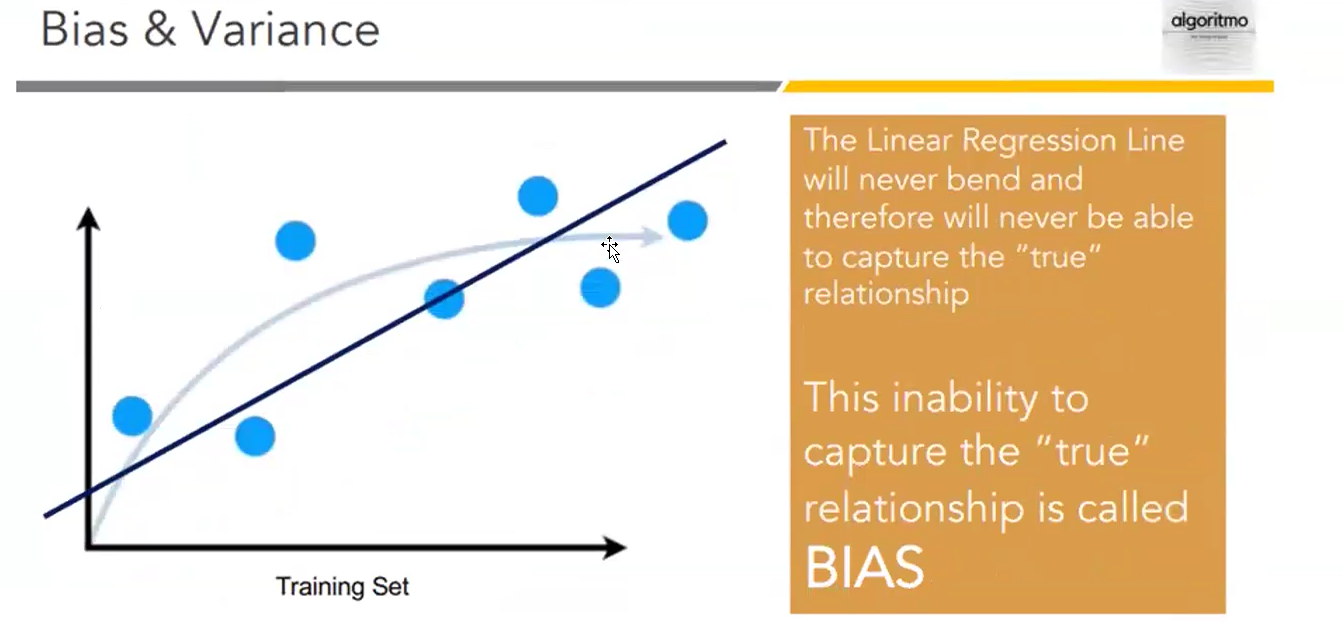

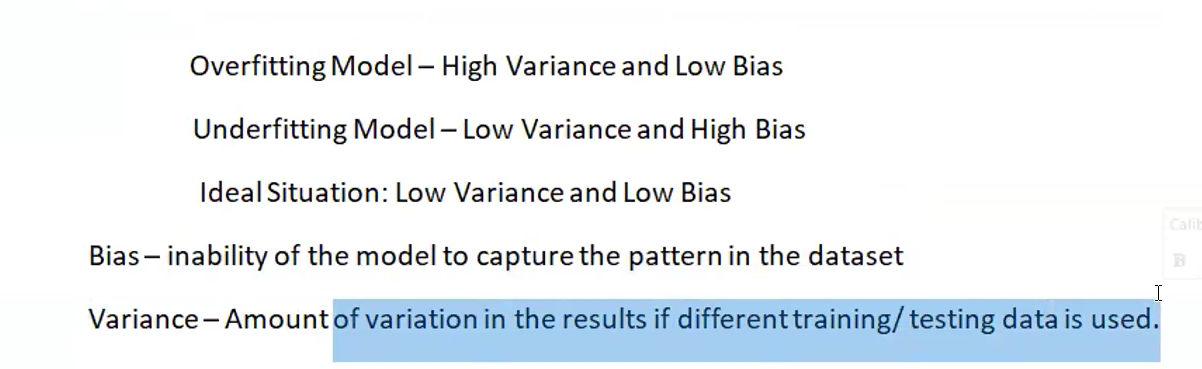

In [ ]:
#training results is goiod and testing is bad -- > over fiting
#training results are bad and testing also bad --- > under fitting